In [2]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", message=".*pyarrow version.*")

import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.model_selection import ParameterSampler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from lightgbm import LGBMClassifier


# ---Notebook configuration---------------------------------------------------
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")


# ---Project paths------------------------------------------------------------
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

DEV_DATA_PATH = PROCESSED_DATA_DIR / "dev_modeling_dataset.parquet"
TUNING_RESULTS_PATH = PROCESSED_DATA_DIR / "lightgbm_tuning_results.csv"
BEST_PARAMS_PATH = PROCESSED_DATA_DIR / "lightgbm_best_params.json"


# ---Sanity check-------------------------------------------------------------
print("Project root:", PROJECT_ROOT.resolve())
print("Development dataset path:", DEV_DATA_PATH.resolve())
print("File exists:", DEV_DATA_PATH.exists())
print()



Project root: C:\Users\zeina
Development dataset path: C:\Users\zeina\data\processed\dev_modeling_dataset.parquet
File exists: True



# Define Modeling Inputs

In [3]:
df = pd.read_parquet(DEV_DATA_PATH)

print("Dataset loaded successfully.")
print()
print("Dataset shape:", df.shape)
print()
print("Target distribution:")
print(df["isFraud"].value_counts(normalize=True))
print()


# ---Target variable----------------------------------------------------------
target_col = "isFraud"

y = df[target_col]
X = df.drop(columns=[target_col])

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Number of features:", X.shape[1])
print()


Dataset loaded successfully.

Dataset shape: (472432, 464)

Target distribution:
isFraud
0   0.9649
1   0.0351
Name: proportion, dtype: float64

Feature matrix shape: (472432, 463)
Target vector shape: (472432,)
Number of features: 463



# Time-Aware Train / Validation Split

In [4]:
# ---Create time-aware split--------------------------------------------------
n_rows = len(X)
split_index = int(n_rows * 0.8)

X_train = X.iloc[:split_index].copy()
X_valid = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_valid = y.iloc[split_index:].copy()


# ---Sanity check-------------------------------------------------------------
print("Train shape:", X_train.shape)
print("Validation shape:", X_valid.shape)
print()
print("Fraud rate (train):", y_train.mean())
print("Fraud rate (valid):", y_valid.mean())
print()


# ---Detect feature types-----------------------------------------------------
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print()


Train shape: (377945, 463)
Validation shape: (94487, 463)

Fraud rate (train): 0.03411872097792007
Fraud rate (valid): 0.039201159947929345

Numeric features: 428
Categorical features: 35



# Build Preprocessing Pipelines

In [5]:
# ---Numeric preprocessing----------------------------------------------------
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)


# ---Categorical preprocessing------------------------------------------------
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)


# ---Column transformer-------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)


# ---Reusable evaluation function---------------------------------------------
def evaluate_model(model_name, fitted_model, X_valid, y_valid, threshold=0.5):
    y_pred_proba = fitted_model.predict_proba(X_valid)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)

    metrics = pd.DataFrame({
        "model": [model_name],
        "roc_auc": [roc_auc_score(y_valid, y_pred_proba)],
        "pr_auc": [average_precision_score(y_valid, y_pred_proba)],
        "precision": [precision_score(y_valid, y_pred, zero_division=0)],
        "recall": [recall_score(y_valid, y_pred, zero_division=0)],
        "f1": [f1_score(y_valid, y_pred, zero_division=0)],
    })

    return metrics, y_pred_proba, y_pred


# Baseline Candidate Model

In [6]:
# ---Define baseline LightGBM model-------------------------------------------
baseline_lgbm_classifier = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

baseline_lgbm_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", baseline_lgbm_classifier),
    ]
)


# ---Train baseline model-----------------------------------------------------
baseline_lgbm_model.fit(X_train, y_train)

print("Baseline LightGBM training complete.")
print()


# ---Baseline validation metrics----------------------------------------------
baseline_results, baseline_pred_proba, baseline_pred = evaluate_model(
    model_name="LightGBM Baseline",
    fitted_model=baseline_lgbm_model,
    X_valid=X_valid,
    y_valid=y_valid,
)

baseline_results


Baseline LightGBM training complete.



,model,roc_auc,pr_auc,precision,recall,f1
0,LightGBM Baseline,0.9184,0.5812,0.2346,0.7732,0.3600


# Hyperparameter Tuning

In [7]:
# ---Focused search space-----------------------------------------------------
param_distributions = {
    "n_estimators": [200, 300, 500, 700],
    "learning_rate": [0.03, 0.05, 0.07],
    "num_leaves": [31, 63, 127],
    "max_depth": [-1, 8, 12],
    "min_child_samples": [20, 50, 100],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "reg_alpha": [0.0, 0.1, 0.5, 1.0],
    "reg_lambda": [0.0, 0.1, 0.5, 1.0],
}


# ---Sample candidate configurations------------------------------------------
n_iter = 24

candidate_params = list(
    ParameterSampler(
        param_distributions=param_distributions,
        n_iter=n_iter,
        random_state=42,
    )
)

print(f"Number of tuning candidates: {len(candidate_params)}")
print()


# ---Run manual search on fixed validation split------------------------------
tuning_records = []

best_pr_auc = -np.inf
best_candidate_index = None
best_candidate_pipeline = None
best_candidate_pred_proba = None
best_candidate_pred = None

for candidate_index, params in enumerate(candidate_params, start=1):
    candidate_classifier = LGBMClassifier(
        objective="binary",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1,
        **params,
    )

    candidate_model = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            ("classifier", candidate_classifier),
        ]
    )

    candidate_model.fit(X_train, y_train)

    candidate_results, candidate_pred_proba, candidate_pred = evaluate_model(
        model_name=f"LightGBM Candidate {candidate_index}",
        fitted_model=candidate_model,
        X_valid=X_valid,
        y_valid=y_valid,
    )

    candidate_record = {
        "candidate_index": candidate_index,
        **params,
        "roc_auc": candidate_results.loc[0, "roc_auc"],
        "pr_auc": candidate_results.loc[0, "pr_auc"],
        "precision": candidate_results.loc[0, "precision"],
        "recall": candidate_results.loc[0, "recall"],
        "f1": candidate_results.loc[0, "f1"],
    }

    tuning_records.append(candidate_record)

    if candidate_record["pr_auc"] > best_pr_auc:
        best_pr_auc = candidate_record["pr_auc"]
        best_candidate_index = candidate_index
        best_candidate_pipeline = candidate_model
        best_candidate_pred_proba = candidate_pred_proba
        best_candidate_pred = candidate_pred

    if candidate_index == 1 or candidate_index % 5 == 0 or candidate_index == len(candidate_params):
        print(
            f"Completed {candidate_index:>2}/{len(candidate_params)} candidates | "
            f"Current best candidate: {best_candidate_index} | "
            f"Best PR-AUC: {best_pr_auc:.4f}"
        )

print()
print("Hyperparameter search complete.")
print()


# ---Collect tuning results---------------------------------------------------
tuning_results = pd.DataFrame(tuning_records).sort_values(
    by=["pr_auc", "roc_auc"],
    ascending=False,
).reset_index(drop=True)

tuning_results


# ---Extract best parameter set-----------------------------------------------
best_params = {
    "n_estimators": int(tuning_results.loc[0, "n_estimators"]),
    "learning_rate": float(tuning_results.loc[0, "learning_rate"]),
    "num_leaves": int(tuning_results.loc[0, "num_leaves"]),
    "max_depth": int(tuning_results.loc[0, "max_depth"]),
    "min_child_samples": int(tuning_results.loc[0, "min_child_samples"]),
    "subsample": float(tuning_results.loc[0, "subsample"]),
    "colsample_bytree": float(tuning_results.loc[0, "colsample_bytree"]),
    "reg_alpha": float(tuning_results.loc[0, "reg_alpha"]),
    "reg_lambda": float(tuning_results.loc[0, "reg_lambda"]),
}

best_params_df = pd.DataFrame([best_params])
best_params_df


Number of tuning candidates: 24

Completed  1/24 candidates | Current best candidate: 1 | Best PR-AUC: 0.6065
Completed  5/24 candidates | Current best candidate: 2 | Best PR-AUC: 0.6069
Completed 10/24 candidates | Current best candidate: 2 | Best PR-AUC: 0.6069
Completed 15/24 candidates | Current best candidate: 13 | Best PR-AUC: 0.6150
Completed 20/24 candidates | Current best candidate: 13 | Best PR-AUC: 0.6150
Completed 24/24 candidates | Current best candidate: 23 | Best PR-AUC: 0.6154

Hyperparameter search complete.



,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,reg_alpha,reg_lambda
0,500,0.0700,127,-1,100,0.7000,0.8000,0.5000,0.0000


# Best Tuned Model

In [8]:
# ---Define tuned model-------------------------------------------------------
tuned_lgbm_classifier = LGBMClassifier(
    objective="binary",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    **best_params,
)

tuned_lgbm_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", tuned_lgbm_classifier),
    ]
)


# ---Train tuned model--------------------------------------------------------
tuned_lgbm_model.fit(X_train, y_train)

print("Tuned LightGBM training complete.")
print()


# ---Tuned validation metrics-------------------------------------------------
tuned_results, tuned_pred_proba, tuned_pred = evaluate_model(
    model_name="LightGBM Tuned",
    fitted_model=tuned_lgbm_model,
    X_valid=X_valid,
    y_valid=y_valid,
)

tuned_results

Tuned LightGBM training complete.



,model,roc_auc,pr_auc,precision,recall,f1
0,LightGBM Tuned,0.9222,0.6154,0.5266,0.6139,0.5669


# Baseline vs Tuned Comparison

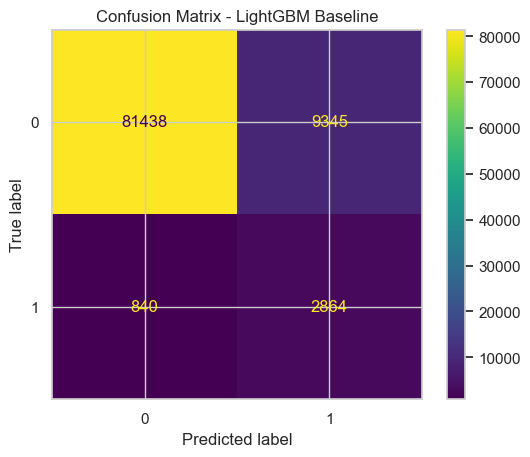

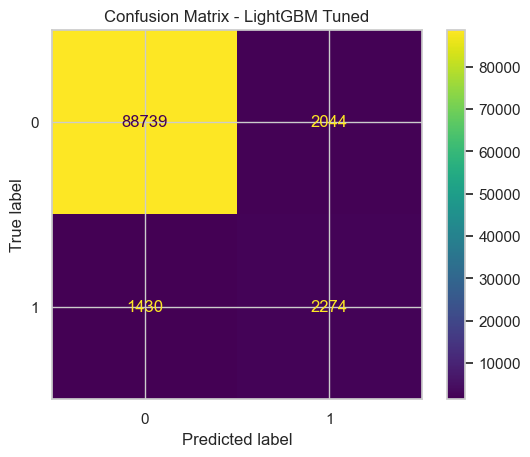

<Figure size 800x600 with 0 Axes>

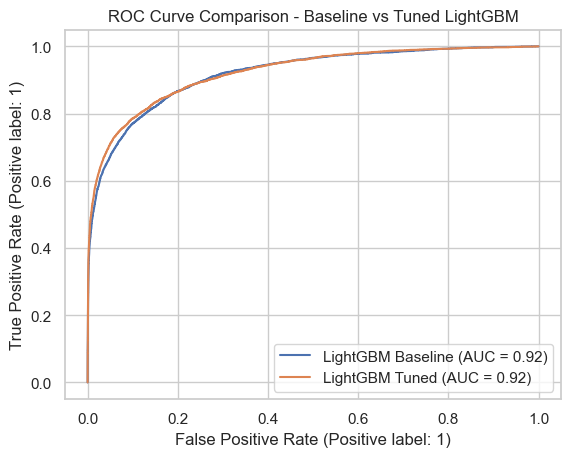

<Figure size 800x600 with 0 Axes>

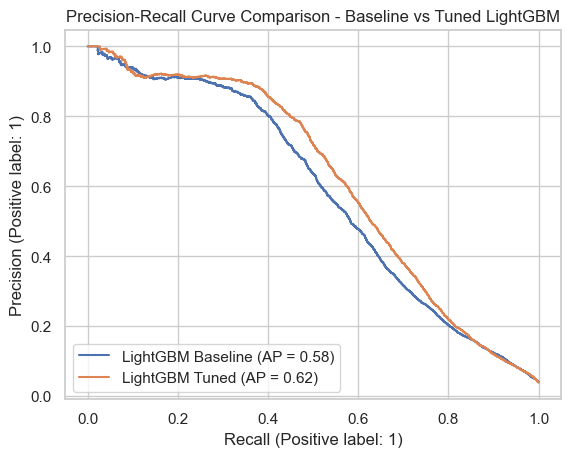

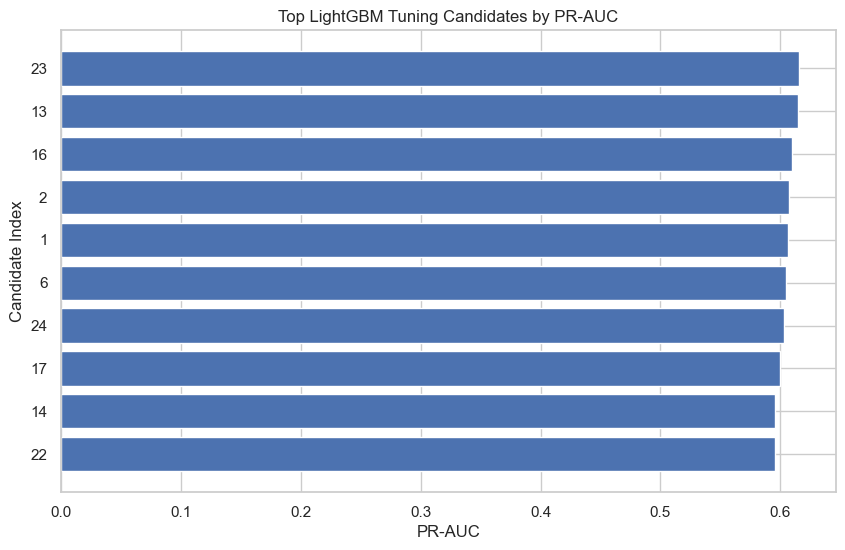

In [10]:
# ---Combine model results----------------------------------------------------
tuning_comparison = pd.concat(
    [baseline_results, tuned_results],
    ignore_index=True,
)

tuning_comparison["roc_auc_delta_vs_baseline"] = (
    tuning_comparison["roc_auc"] - baseline_results.loc[0, "roc_auc"]
)
tuning_comparison["pr_auc_delta_vs_baseline"] = (
    tuning_comparison["pr_auc"] - baseline_results.loc[0, "pr_auc"]
)
tuning_comparison["precision_delta_vs_baseline"] = (
    tuning_comparison["precision"] - baseline_results.loc[0, "precision"]
)
tuning_comparison["recall_delta_vs_baseline"] = (
    tuning_comparison["recall"] - baseline_results.loc[0, "recall"]
)
tuning_comparison["f1_delta_vs_baseline"] = (
    tuning_comparison["f1"] - baseline_results.loc[0, "f1"]
)

tuning_comparison

# ---Top tuning candidates----------------------------------------------------
top_tuning_candidates = tuning_results.head(10).copy()
top_tuning_candidates

# ---Confusion matrix: baseline-----------------------------------------------
baseline_cm = confusion_matrix(y_valid, baseline_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=baseline_cm)
disp.plot()

plt.title("Confusion Matrix - LightGBM Baseline")
plt.show()


# ---Confusion matrix: tuned--------------------------------------------------
tuned_cm = confusion_matrix(y_valid, tuned_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=tuned_cm)
disp.plot()

plt.title("Confusion Matrix - LightGBM Tuned")
plt.show()


# ---ROC comparison-----------------------------------------------------------
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_valid,
    baseline_pred_proba,
    name="LightGBM Baseline",
)

RocCurveDisplay.from_predictions(
    y_valid,
    tuned_pred_proba,
    name="LightGBM Tuned",
    ax=plt.gca(),
)

plt.title("ROC Curve Comparison - Baseline vs Tuned LightGBM")
plt.show()


# ---PR comparison------------------------------------------------------------
plt.figure(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(
    y_valid,
    baseline_pred_proba,
    name="LightGBM Baseline",
)

PrecisionRecallDisplay.from_predictions(
    y_valid,
    tuned_pred_proba,
    name="LightGBM Tuned",
    ax=plt.gca(),
)

plt.title("Precision-Recall Curve Comparison - Baseline vs Tuned LightGBM")
plt.show()


# ---Top-candidate PR-AUC plot------------------------------------------------
plot_df = top_tuning_candidates.sort_values(by="pr_auc", ascending=True).copy()

plt.figure(figsize=(10, 6))
plt.barh(
    y=plot_df["candidate_index"].astype(str),
    width=plot_df["pr_auc"],
)
plt.xlabel("PR-AUC")
plt.ylabel("Candidate Index")
plt.title("Top LightGBM Tuning Candidates by PR-AUC")
plt.show()

# Save Tuning Outputs

In [11]:
# ---Save tuning results------------------------------------------------------
tuning_results.to_csv(TUNING_RESULTS_PATH, index=False)

with open(BEST_PARAMS_PATH, "w", encoding="utf-8") as file:
    json.dump(best_params, file, indent=4)

print("Tuning results saved to:", TUNING_RESULTS_PATH.resolve())
print("Best parameter file saved to:", BEST_PARAMS_PATH.resolve())
print()


# ---Final selected model summary---------------------------------------------
selected_model_summary = pd.DataFrame({
    "selected_model": ["LightGBM Tuned"],
    "selection_metric": ["PR-AUC"],
    "validation_roc_auc": [tuned_results.loc[0, "roc_auc"]],
    "validation_pr_auc": [tuned_results.loc[0, "pr_auc"]],
    "validation_precision": [tuned_results.loc[0, "precision"]],
    "validation_recall": [tuned_results.loc[0, "recall"]],
    "validation_f1": [tuned_results.loc[0, "f1"]],
})

selected_model_summary

Tuning results saved to: C:\Users\zeina\data\processed\lightgbm_tuning_results.csv
Best parameter file saved to: C:\Users\zeina\data\processed\lightgbm_best_params.json



,selected_model,selection_metric,validation_roc_auc,validation_pr_auc,validation_precision,validation_recall,validation_f1
0,LightGBM Tuned,PR-AUC,0.9222,0.6154,0.5266,0.6139,0.5669


## Overview
In this notebook we performed hyperparameter tuning for the LightGBM model using the development dataset.
The objective of tuning was to improve fraud detection performance while maintaining the same time-aware train/validation split used in the previous notebook to ensure consistent evaluation.

A focused parameter search was conducted using 24 candidate configurations, sampled from a constrained hyperparameter space covering tree complexity, sampling behavior, and regularization.

The model selection metric was PR-AUC (Average Precision), which is more informative than ROC-AUC for highly imbalanced classification problems such as fraud detection.

## Interpretation

The tuned model shows improved ranking performance compared to the baseline LightGBM model trained in the previous notebook.
The improvement is most visible in PR-AUC, indicating that the tuned model is more effective at prioritizing fraudulent transactions near the top of the score distribution.

This is particularly important in fraud detection settings where fraud events represent a small fraction of total transactions (~3.5% in this dataset) and operational teams typically review only the highest-risk transactions.

Improving PR-AUC therefore translates directly into better fraud concentration within the highest risk scores, which improves the efficiency of manual review processes.

The final tuned LightGBM model will be carried forward as the candidate model for final validation and deployment evaluation in the subsequent notebooks.